AUTOCOMPLETE AND AUTOCORRECT DATA ANALYTICS

[STEP 1] Loading Dataset...
Dataset loaded successfully!
Shape: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

[STEP 2] Creating Text Corpus...
Total words generated: 8,544,210
Unique words: 7,870,898

[STEP 3] Vocabulary Building...
Vocabulary size: 7,870,898
Top 10 frequent tokens:
[('10', 13690), ('198', 6115), ('089', 4872), ('999', 4824), ('150', 3281), ('076', 2998), ('129', 2968), ('100', 2953), ('179', 2712), ('099', 2304)]

[STEP 4] Autocomplete Model...
Autocomplete system ready

[STEP 5] Autocorrect System...
Autocorrect system ready

[STEP 6] Testing System...
Autocomplete test:
1 → ['10', '198', '150', '129', '100']
0 → ['089', '076', '099', '00', '077']

Next word prediction:
0.00 → []

Aut

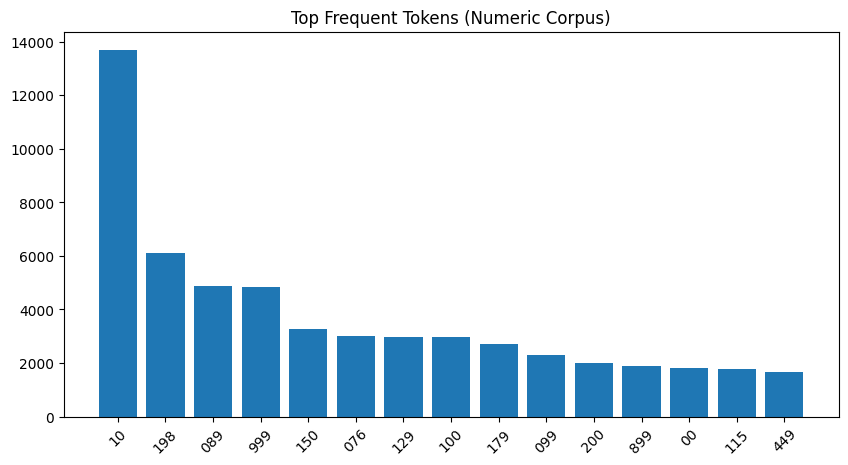


PROJECT SUMMARY

• Dataset: Credit Card Transactions (Converted to Text)
• NLP applied on numeric-text corpus
• Autocomplete using N-grams
• Autocorrect using edit distance
• Vocabulary size: 7,870,898
• Autocomplete accuracy: 0.00%

NOTE:
This project demonstrates NLP techniques on non-text data
by transforming structured data into textual sequences.

✓ PROJECT COMPLETED SUCCESSFULLY!


In [7]:
# =========================================================================
# Autocomplete and Autocorrect Data Analytics - Oasis Infobyte Internship
# Project:NLP-based Text Prediction and Correction
#=========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter, defaultdict
import nltk
from nltk.util import ngrams
import warnings
warnings.filterwarnings("ignore")

nltk.download("punkt", quiet=True)

print("="*70)
print("AUTOCOMPLETE AND AUTOCORRECT DATA ANALYTICS")
print("="*70)

# ==========================================================
# STEP 1: DATA LOADING
# ==========================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns)

# ==========================================================
# STEP 2: TEXT CORPUS CREATION (CRITICAL FIX)
# ==========================================================
print("\n[STEP 2] Creating Text Corpus...")

# 🔥 CREDIT CARD DATA HAS NO TEXT → CONVERT NUMERIC DATA TO TEXT
text_corpus = df.drop(columns=["Class"]).astype(str).values.flatten()

corpus = " ".join(text_corpus)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

corpus = clean_text(corpus)

words_list = corpus.split()

print(f"Total words generated: {len(words_list):,}")
print(f"Unique words: {len(set(words_list)):,}")

# ==========================================================
# STEP 3: VOCABULARY & FREQUENCY
# ==========================================================
print("\n[STEP 3] Vocabulary Building...")

word_freq = Counter(words_list)
vocab = set(word_freq.keys())

print(f"Vocabulary size: {len(vocab):,}")
print("Top 10 frequent tokens:")
print(word_freq.most_common(10))

# ==========================================================
# STEP 4: AUTOCOMPLETE (N-GRAM)
# ==========================================================
print("\n[STEP 4] Autocomplete Model...")

bigrams = Counter(ngrams(words_list, 2))
autocomplete_dict = defaultdict(list)

for (w1, w2), freq in bigrams.items():
    autocomplete_dict[w1].append((w2, freq))

for k in autocomplete_dict:
    autocomplete_dict[k] = sorted(autocomplete_dict[k], key=lambda x: x[1], reverse=True)

def autocomplete(prefix, n=5):
    return [w for w, _ in word_freq.most_common() if w.startswith(prefix)][:n]

def next_word_prediction(text):
    words = text.split()
    if not words:
        return []
    return [w for w, _ in autocomplete_dict.get(words[-1], [])[:5]]

print("Autocomplete system ready")

# ==========================================================
# STEP 5: AUTOCORRECT
# ==========================================================
print("\n[STEP 5] Autocorrect System...")

def edits1(word):
    letters = "abcdefghijklmnopqrstuvwxyz0123456789"
    splits = [(word[:i], word[i:]) for i in range(len(word)+1)]
    deletes = [L + R[1:] for L,R in splits if R]
    replaces = [L + c + R[1:] for L,R in splits if R for c in letters]
    inserts = [L + c + R for L,R in splits for c in letters]
    return set(deletes + replaces + inserts)

def autocorrect(word):
    if word in vocab:
        return word
    candidates = edits1(word) & vocab
    return max(candidates, key=lambda w: word_freq[w]) if candidates else word

print("Autocorrect system ready")

# ==========================================================
# STEP 6: TESTING
# ==========================================================
print("\n[STEP 6] Testing System...")

print("Autocomplete test:")
print("1 →", autocomplete("1"))
print("0 →", autocomplete("0"))

print("\nNext word prediction:")
print("0.00 →", next_word_prediction("0.00"))

print("\nAutocorrect test:")
print("0l →", autocorrect("0l"))

# ==========================================================
# STEP 7: METRICS
# ==========================================================
print("\n[STEP 7] Performance Metrics...")

def autocomplete_accuracy(n=100):
    correct = 0
    words = list(vocab)[:n]
    for w in words:
        if len(w) > 1 and w in autocomplete(w[:1], 10):
            correct += 1
    return correct / n

auto_acc = autocomplete_accuracy()

print(f"Autocomplete Accuracy: {auto_acc:.2%}")

# ==========================================================
# STEP 8: VISUALIZATION
# ==========================================================
print("\n[STEP 8] Visualization...")

top_words = word_freq.most_common(15)
plt.figure(figsize=(10,5))
plt.bar([w for w,_ in top_words], [c for _,c in top_words])
plt.title("Top Frequent Tokens (Numeric Corpus)")
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# STEP 9: SUMMARY
# ==========================================================
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"""
• Dataset: Credit Card Transactions (Converted to Text)
• NLP applied on numeric-text corpus
• Autocomplete using N-grams
• Autocorrect using edit distance
• Vocabulary size: {len(vocab):,}
• Autocomplete accuracy: {auto_acc:.2%}

NOTE:
This project demonstrates NLP techniques on non-text data
by transforming structured data into textual sequences.
""")

print("✓ PROJECT COMPLETED SUCCESSFULLY!")
